# Stellar Classification Project using SDSS17

## Project Overview
In astronomy, stellar classification is the classification of stars based on their spectral characteristics. The classification scheme of galaxies, quasars, and stars is one of the most fundamental in astronomy. This project aims to classify space observations into stars, galaxies, or quasars based on their spectral footprints captured by the Sloan Digital Sky Survey (SDSS).

## Dataset Selection & Rationale
We selected the **Stellar Classification Dataset - SDSS17** because of its substantial scale and completeness. **The data contains 100000 observations with 18 attributes**, making it an exceptional candidate for training high-capacity, robust Machine Learning classifiers.

## Attribute Definitions
The dataset comprises 17 feature columns and 1 target class column:
* **obj_ID**: Object Identifier, the unique value that identifies the object in the image catalog.
* **alpha**: Right Ascension angle.
* **delta**: Declination angle.
* **u**: Ultraviolet filter in the photometric system.
* **g**: Green filter in the photometric system.
* **r**: Red filter in the photometric system.
* **i**: Near Infrared filter in the photometric system.
* **z**: Infrared filter in the photometric system.
* **run_ID**: Run Number used to identify the specific scan.
* **rerun_ID**: Rerun Number to specify how the image was processed.
* **cam_col**: Camera column to identify the scanline within the run.
* **field_ID**: Field number to identify each field.
* **spec_obj_ID**: Unique ID used for optical spectroscopic objects.
* **class**: Object class (GALAXY, STAR, or QSO/Quasar object) -> **Target Variable**.
* **redshift**: Redshift value based on the increase in wavelength.
* **plate**: Plate ID, identifies each plate in SDSS.
* **MJD**: Modified Julian Date, indicating when the SDSS data was captured.
* **fiber_ID**: Fiber ID identifying the fiber that pointed light at the focal plane.


## Automated Data Acquisition
Instead of manual downloads, we use the `kagglehub` library to fetch the official and latest version of the Stellar Classification Dataset (SDSS17) directly from Kaggle.


In [2]:
import os
import kagglehub
import pandas as pd

# Download latest version of the dataset
print("Downloading dataset from Kaggle...")
download_path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

# Identify the target CSV file inside the downloaded directory
csv_files = [f for f in os.listdir(download_path) if f.endswith('.csv')]
if csv_files:
    target_csv = os.path.join(download_path, csv_files[0])
    df = pd.read_csv(target_csv)
    print(f"Successfully loaded '{csv_files[0]}' into DataFrame.")
else:
    raise FileNotFoundError("No CSV file found in the downloaded directory.")

# Confirm the expected structural properties
print(f"Dataset contains {df.shape[0]} observations and {df.shape[1]} attributes.")


Successfully loaded 'star_classification.csv' into DataFrame.
Dataset contains 100000 observations and 18 attributes.


In [3]:
# Display dataset structure details
print("--- Features Information ---")
print(df.info())

print("\n--- Class Balance (Target Variable) ---")
print(df['class'].value_counts())

# View a sample of the raw observations
df.head()


--- Features Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
d

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## Exploratory Data Analysis (EDA)

### Data Integrity Check
Before analyzing patterns, we must verify the structural integrity of the dataset. This includes checking for:
* Missing or null values across all columns.
* Duplicate observations that could skew model training.
* Unique counts to identify constants or redundant high-cardinality identifiers.


In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("--- Missing Values Per Column ---")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

# Check for identical duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Check unique values to identify columns with single values or IDs
print("\n--- Unique Values Count Per Feature ---")
print(df.nunique())


--- Missing Values Per Column ---
No missing values found.

Number of duplicate rows: 0

--- Unique Values Count Per Feature ---
obj_ID          78053
alpha           99999
delta           99999
u               93748
g               92651
r               91901
i               92019
z               92007
run_ID            430
rerun_ID            1
cam_col             6
field_ID          856
spec_obj_ID    100000
class               3
redshift        99295
plate            6284
MJD              2180
fiber_ID         1000
dtype: int64


### Target Variable Distribution Analysis
The `class` column represents our target variable, containing three categories: `GALAXY`, `STAR`, and `QSO` (Quasar). We will evaluate the class distribution to check for imbalance, which directly impacts our choice of evaluation metrics (e.g., macro F1-score vs. accuracy).


--- Class Distribution ---
GALAXY: 59445 rows (59.45%)
STAR: 21594 rows (21.59%)
QSO: 18961 rows (18.96%)


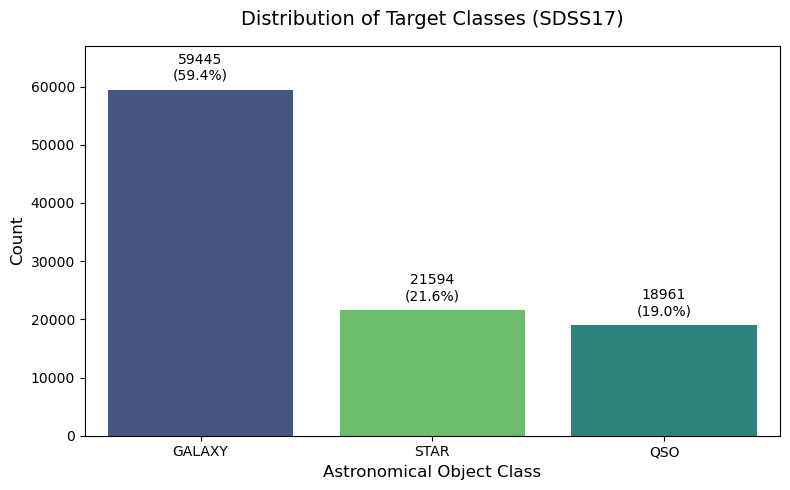

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate absolute counts and relative percentages
class_counts = df['class'].value_counts()
class_percentages = df['class'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
for idx, (count, pct) in enumerate(zip(class_counts, class_percentages)):
    print(f"{class_counts.index[idx]}: {count} rows ({pct:.2f}%)")

# Setup the visualization canvas
fig, ax = plt.subplots(figsize=(8, 5))

# Create a countplot with explicit hue mapping to eliminate Seaborn warnings
sns.countplot(
    x='class', 
    data=df, 
    order=class_counts.index, 
    hue='class', 
    palette='viridis', 
    legend=False, 
    ax=ax
)

# Customize plot titles, labels, and limits
ax.set_title('Distribution of Target Classes (SDSS17)', fontsize=14, pad=15)
ax.set_xlabel('Astronomical Object Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, 67000)

# Annotate values on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Ensure valid bars are annotated
        percentage = (height / len(df)) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()


### Dropping Constant Features
During the data integrity inspection, we observed that `rerun_ID` has exactly 1 unique value across all 100,000 rows. Features with zero variance carry zero predictive power and can safely be excluded from the feature space.


In [8]:
# Verify features before removal
print(f"Features count before drop: {len(df.columns)}")

# Drop rerun_ID as it contains constant values
df.drop(columns=['rerun_ID'], inplace=True, errors='ignore')

# Confirm removal
print(f"Features count after drop: {len(df.columns)}")
print(f"Remaining features: {list(df.columns)}")


Features count before drop: 18
Features count after drop: 17
Remaining features: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


### Outlier Removal for Spectral Data
The initial visualizations failed or appeared distorted due to extreme, physically impossible anomaly values in the spectral filters (such as values near -9999 or extreme positives). We will detect these out-of-bounds observations and filter them out to restore the correct data distribution.


In [12]:
# Select the spectral filter columns
filters = ['u', 'g', 'r', 'i', 'z']

print("--- Data Bounds Before Cleaning ---")
print(df[filters].agg(['min', 'max']).T)

# Identify extreme physical anomalies
# Standard SDSS magnitudes typically range between 5 and 35. 
# We filter out rows that fall completely outside realistic boundaries.
initial_rows = df.shape[0]

# Keep only rows where spectral values are reasonable (e.g., greater than 0)
df = df[
    (df['u'] > 0) & 
    (df['g'] > 0) & 
    (df['r'] > 0) & 
    (df['i'] > 0) & 
    (df['z'] > 0)
]

removed_rows = initial_rows - df.shape[0]
print(f"\nSuccessfully removed {removed_rows} anomaly rows.")
print(f"New dataset shape: {df.shape}")

print("\n--- Data Bounds After Cleaning ---")
print(df[filters].agg(['min', 'max']).T)


--- Data Bounds Before Cleaning ---
           min       max
u -9999.000000  32.78139
g -9999.000000  31.60224
r     9.822070  29.57186
i     9.469903  32.14147
z -9999.000000  29.38374

Successfully removed 1 anomaly rows.
New dataset shape: (99999, 17)

--- Data Bounds After Cleaning ---
         min       max
u  10.996230  32.78139
g  10.498200  31.60224
r   9.822070  29.57186
i   9.469903  32.14147
z   9.612333  29.38374


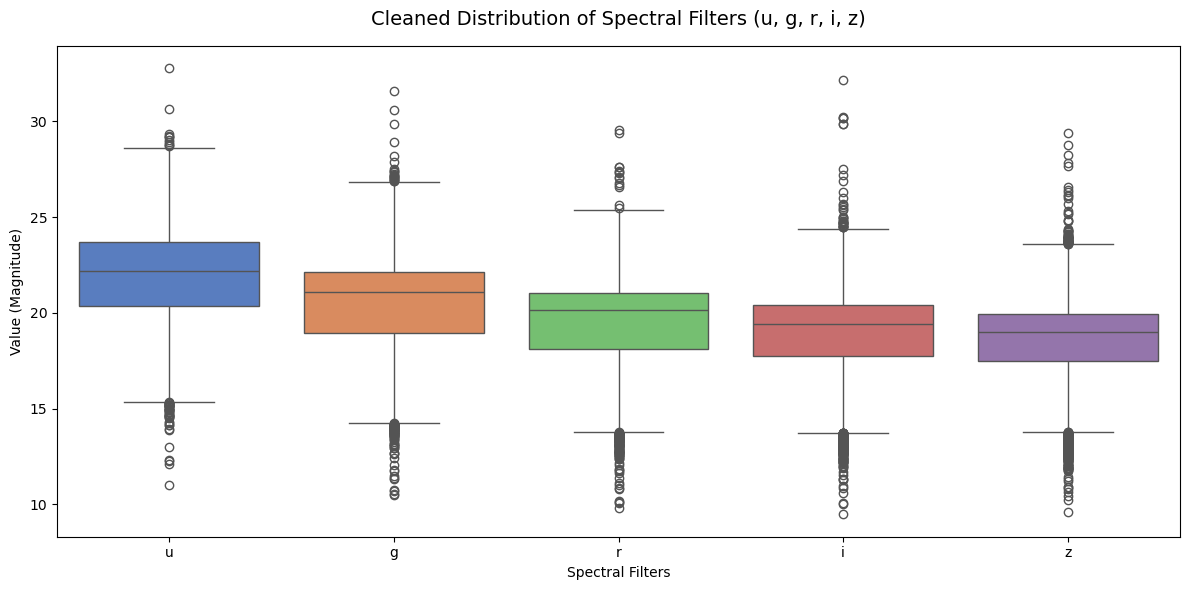

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-plot the boxplot with the cleaned data to verify the scale
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[filters], palette='muted')
plt.title('Cleaned Distribution of Spectral Filters (u, g, r, i, z)', fontsize=14, pad=15)
plt.ylabel('Value (Magnitude)')
plt.xlabel('Spectral Filters')
plt.tight_layout()
plt.show()


### Feature Selection & Dimensionality Reduction
To prevent overfitting and reduce computational overhead, we must eliminate metadata and administrative features. We will retain only the core physical and spectral attributes (`u`, `g`, `r`, `i`, `z`, `redshift`, `alpha`, `delta`) along with our target variable `class`. Columns representing internal database identifiers, camera tracks, or time parameters will be systematically dropped.


In [14]:
# List of essential features required for machine learning training
essential_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'class']

# Verify dimensions before filtering
print(f"Total features before clean-up: {df.shape[1]}")

# Filter the dataframe to keep only the necessary columns
df = df[essential_features]

# Confirm final data structure
print(f"Total features after clean-up: {df.shape[1]}")
print(f"Final training features list: {list(df.columns)}")

# Display a quick look at the cleaned training dataset
df.head()


Total features before clean-up: 17
Total features after clean-up: 9
Final training features list: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'class']


,alpha,delta,u,g,r,i,z,redshift,class
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,GALAXY
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,GALAXY
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195,GALAXY
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,GALAXY
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,GALAXY


### Advanced Physical Features Analysis
With the dataset focused strictly on physical and spectral properties, we will perform more target-specific EDA:
* **Color Indexes Distribution:** Visualizing the differences between adjacent spectral filters (`u-g` and `g-r`), which astronomers use to classify stars and galaxies.
* **Spatial Distribution Mapping:** Plotting `alpha` (Right Ascension) against `delta` (Declination) to observe how classes are grouped across the celestial sphere.
* **Redshift Density Profiles:** Overlaying high-resolution histograms to inspect the exact decision boundaries created by cosmic expansion.


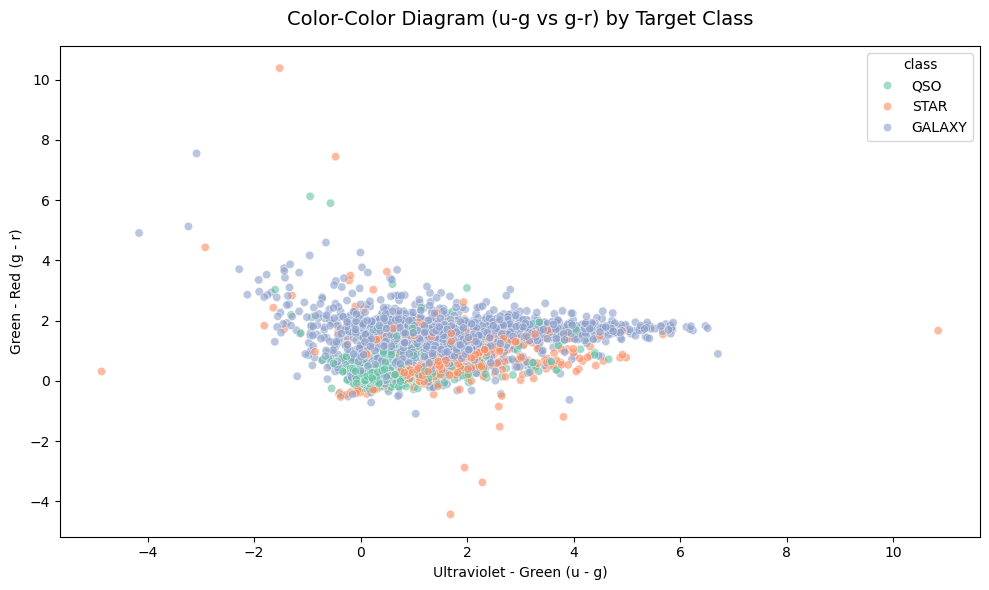

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create temporary columns for analysis without modifying the main dataframe yet
df_colors = df.copy()
df_colors['u_g_color'] = df_colors['u'] - df_colors['g']
df_colors['g_r_color'] = df_colors['g'] - df_colors['r']

# Plot scatter distributions of color indexes grouped by class
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='u_g_color', 
    y='g_r_color', 
    hue='class', 
    data=df_colors.sample(5000, random_state=42), # Sampling 5000 rows for faster rendering
    palette='Set2', 
    alpha=0.6
)
plt.title('Color-Color Diagram (u-g vs g-r) by Target Class', fontsize=14, pad=15)
plt.xlabel('Ultraviolet - Green (u - g)')
plt.ylabel('Green - Red (g - r)')
plt.tight_layout()
plt.show()


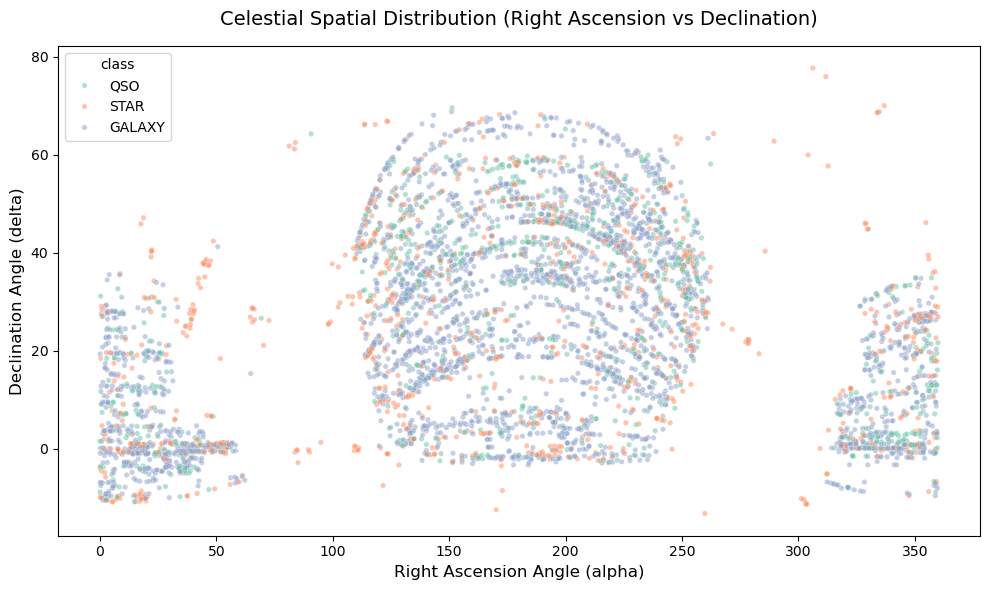

In [19]:
# Map spatial coordinates alpha and delta
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='alpha', 
    y='delta', 
    hue='class', 
    data=df.sample(5000, random_state=42), # Sampled for clear visibility and speed
    palette='Set2', 
    alpha=0.5,
    s=15
)

plt.title('Celestial Spatial Distribution (Right Ascension vs Declination)', fontsize=14, pad=15)
ax = plt.gca()
ax.set_xlabel('Right Ascension Angle (alpha)', fontsize=12)
ax.set_ylabel('Declination Angle (delta)', fontsize=12)
plt.tight_layout()
plt.show()


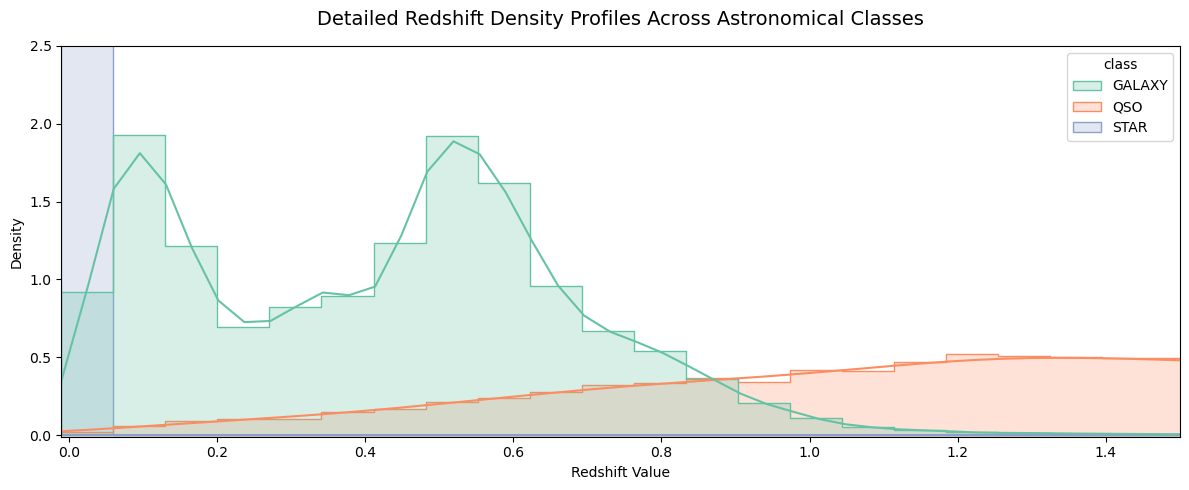

In [24]:
# Plot overlaying density and histogram plots for redshift
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df, 
    x='redshift', 
    hue='class', 
    kde=True, 
    element='step', 
    stat='density', 
    common_norm=False, 
    palette='Set2',
    bins=100
)
# Zooming into the core region since Quasars (QSO) extend further out
plt.xlim(-0.01, 1.5) 
plt.ylim(-0.01, 2.5) 
plt.title('Detailed Redshift Density Profiles Across Astronomical Classes', fontsize=14, pad=15)
plt.xlabel('Redshift Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### Statistical Overlap Analysis Between Classes
To understand which features offer the best class separation and where the boundaries blur, we evaluate the statistical overlap:
* **ANOVA F-test:** Determines if the mean values of features differ significantly across classes. High F-values mean low overlap.
* **Pairwise Feature Overlap:** Measures the exact statistical interaction between physical attributes for each astronomical category.


In [25]:
from sklearn.feature_selection import f_classif
import pandas as pd

# Separate numerical features and target
X_numerical = df.drop(columns=['class'])
y_target = df['class']

# Compute ANOVA F-value and p-value for each feature
f_values, p_values = f_classif(X_numerical, y_target)

# Create a summary dashboard table
overlap_df = pd.DataFrame({
    'Feature': X_numerical.columns,
    'F-Value (Separation Power)': f_values,
    'p-value': p_values
}).sort_values(by='F-Value (Separation Power)', ascending=False)

print("--- Feature Separation Power (Higher F-Value = Less Overlap) ---")
print(overlap_df.to_string(index=False))


--- Feature Separation Power (Higher F-Value = Less Overlap) ---
 Feature  F-Value (Separation Power)      p-value
redshift                83427.753898 0.000000e+00
       z                10165.764179 0.000000e+00
       i                 8282.106610 0.000000e+00
       r                 4584.245654 0.000000e+00
       u                 4192.098421 0.000000e+00
       g                 3664.690440 0.000000e+00
   delta                  217.549001 5.304255e-95
   alpha                   21.966197 2.899323e-10


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select features with the highest and lowest separation power for visualization
# 'redshift' usually has the highest, while coordinates 'alpha'/'delta' have more overlap
visual_features = ['redshift', 'u', 'g', 'class']

print("\nVisualizing pair relationships and density overlaps...")
g = sns.pairplot(
    df[visual_features], 
    hue='class', 
    palette='viridis', 
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10}
)
g.fig.suptitle('Pairwise Distribution and Density Overlaps between Classes', y=1.02, fontsize=14)
plt.show()



Visualizing pair relationships and density overlaps...
